# Inspecting the full pipeline for the VAE

In [35]:
from __future__ import annotations
import numpy as np 
import matplotlib.pyplot as plt
import json
import os
import sys 
import tskit 
from pathlib import Path
import torch

In [36]:
PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [37]:
processed_data_path = Path('/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/processed_data/0/rep0')

In [38]:
# Let's look at the normalized discovery data
norm_discovery = np.load(f'{processed_data_path}/discovery_train.npy')

In [39]:
norm_discovery.shape

(400, 7036)

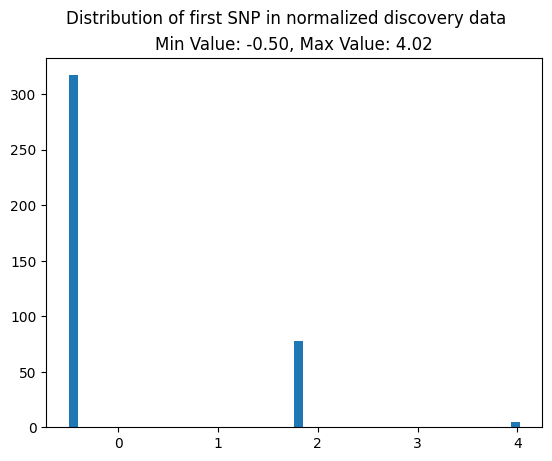

In [40]:
plt.figure()
plt.hist(norm_discovery[:,0], bins=50)
plt.suptitle('Distribution of first SNP in normalized discovery data')
plt.title(f'Min Value: {norm_discovery[:,0].min():.2f}, Max Value: {norm_discovery[:,0].max():.2f}')
plt.show()

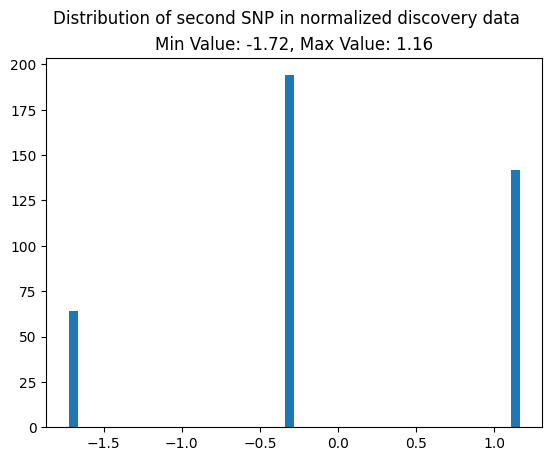

In [41]:
plt.figure()
plt.hist(norm_discovery[:,1], bins=50)
plt.suptitle('Distribution of second SNP in normalized discovery data')
plt.title(f'Min Value: {norm_discovery[:,1].min():.2f}, Max Value: {norm_discovery[:,1].max():.2f}')
plt.show()

In [42]:
print(f'Maximum Value in normalized discovery data: {norm_discovery.max():.2f}')
print(f'Minimum Value in normalized discovery data: {norm_discovery.min():.2f}')

Maximum Value in normalized discovery data: 19.96
Minimum Value in normalized discovery data: -6.42


In [43]:
from src.masking import make_mask_and_apply
x = torch.tensor(norm_discovery[:64], dtype=torch.float32)   # (B, L)

In [44]:
x_in, mask, used_block_len = make_mask_and_apply(
    x,
    enabled=True,
    n_blocks=4,
    block_len=None,       # use mask_frac instead
    mask_frac=0.8,
    allow_overlap=True,
    seed=123,             # deterministic
    fill="gaussian",
    gaussian_std=0.1,
    constant_value=0.0,
)

print(x.shape, x_in.shape, mask.shape, used_block_len)

torch.Size([64, 7036]) torch.Size([64, 7036]) torch.Size([64, 7036]) 1407


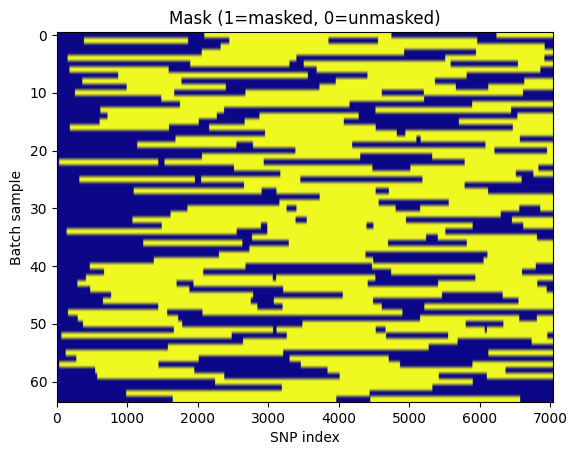

In [45]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(mask.cpu().numpy().astype(float), aspect="auto", cmap = "plasma")
plt.title("Mask (1=masked, 0=unmasked)")
plt.xlabel("SNP index")
plt.ylabel("Batch sample")
plt.show()

Shapes: torch.Size([64, 7036]) torch.Size([64, 7036]) torch.Size([64, 7036]) used_block_len: 176


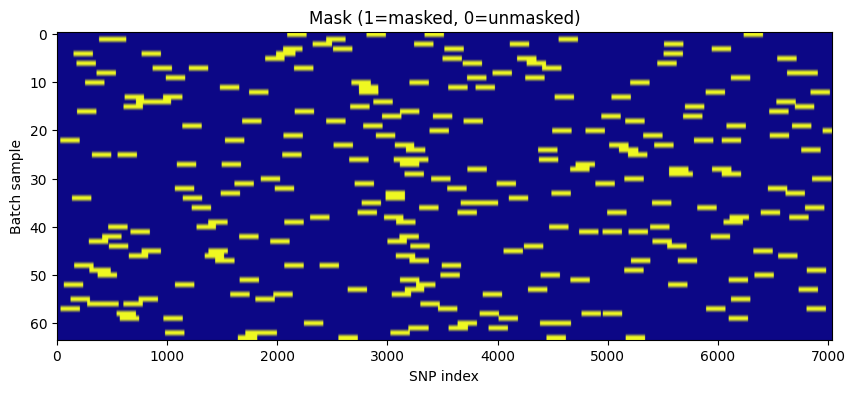

In [46]:
from torch.utils.data import DataLoader, TensorDataset

# --- dataset / loader ---
X = torch.tensor(norm_discovery, dtype=torch.float32)  # (N, L)
ds = TensorDataset(X)
loader = DataLoader(ds, batch_size=64, shuffle=True, num_workers=0, drop_last=True)

batch = next(iter(loader))
x = batch[0]  # (B, L)

# --- apply masking ---
mask_cfg = dict(
    enabled=True,
    n_blocks=4,
    block_len=None,      # use mask_frac instead
    mask_frac=0.1,       # <-- you probably want something like 0.001–0.1 normally; 0.8 is huge but fine for viz
    allow_overlap=True,
    seed=123,
    fill="gaussian",
    gaussian_std=0.1,
    constant_value=0.0,
)

x_in, mask, used_block_len = make_mask_and_apply(x, **mask_cfg)

print("Shapes:", x.shape, x_in.shape, mask.shape, "used_block_len:", used_block_len)

plt.figure(figsize=(10,4))
plt.imshow(mask.numpy().astype(float), aspect="auto", cmap="plasma")
plt.title("Mask (1=masked, 0=unmasked)")
plt.xlabel("SNP index")
plt.ylabel("Batch sample")
plt.show()

In [47]:
from src.vae.model import ConvVAE1D

input_len = norm_discovery.shape[1]

model = ConvVAE1D(
    input_len=input_len,
    latent_dim=64,
    hidden_channels=[64, 128],
    kernel_size=17,
    stride=2,
    padding=8,
    use_batchnorm=False,
)

model.eval()  # we are not training

ConvVAE1D(
  (enc_conv): Sequential(
    (0): Conv1d(1, 64, kernel_size=(17,), stride=(2,), padding=(8,))
    (1): ELU(alpha=1.0, inplace=True)
    (2): Conv1d(64, 128, kernel_size=(17,), stride=(2,), padding=(8,))
    (3): ELU(alpha=1.0, inplace=True)
  )
  (fc_mu): Linear(in_features=225152, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=225152, out_features=64, bias=True)
  (fc_dec): Linear(in_features=64, out_features=225152, bias=True)
  (dec_conv): Sequential(
    (0): ConvTranspose1d(128, 64, kernel_size=(17,), stride=(2,), padding=(8,), output_padding=(1,))
    (1): ELU(alpha=1.0, inplace=True)
    (2): ConvTranspose1d(64, 1, kernel_size=(17,), stride=(2,), padding=(8,), output_padding=(1,))
  )
)

In [48]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from src.masking import make_mask_and_apply

X = torch.tensor(norm_discovery, dtype=torch.float32)
loader = DataLoader(TensorDataset(X), batch_size=64, shuffle=False)

batch = next(iter(loader))
x = batch[0]   # (B, L)

print("Original x shape:", x.shape)

x_in, mask, used_block_len = make_mask_and_apply(
    x,
    enabled=True,
    n_blocks=4,
    block_len=None,
    mask_frac=0.05,   # use something reasonable
    allow_overlap=True,
    seed=123,
    fill="gaussian",
    gaussian_std=0.1,
    constant_value=0.0,
)

print("Masked x_in shape:", x_in.shape)
print("Mask shape:", mask.shape)

Original x shape: torch.Size([64, 7036])
Masked x_in shape: torch.Size([64, 7036])
Mask shape: torch.Size([64, 7036])


In [49]:
with torch.no_grad():
    recon, mu, logvar = model(x_in)

print("Recon shape:", recon.shape)
print("Mu shape:", mu.shape)
print("Logvar shape:", logvar.shape)

Recon shape: torch.Size([64, 7036])
Mu shape: torch.Size([64, 64])
Logvar shape: torch.Size([64, 64])


/sietch_colab/akapoor/PRS_Portability/src/vae/model.py:115: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=False):


In [50]:
start = 1000
end = 1400   # 400 SNP window

plt.figure(figsize=(14,4))
plt.plot(x_i[start:end], label="x (clean)", linewidth=1)
plt.plot(xin_i[start:end], label="x_in (masked)", linewidth=1)
plt.plot(recon_i[start:end], label="recon (random)", linewidth=1)
plt.legend()
plt.title(f"SNPs {start}:{end}")
plt.show()

NameError: name 'x_i' is not defined

<Figure size 1400x400 with 0 Axes>

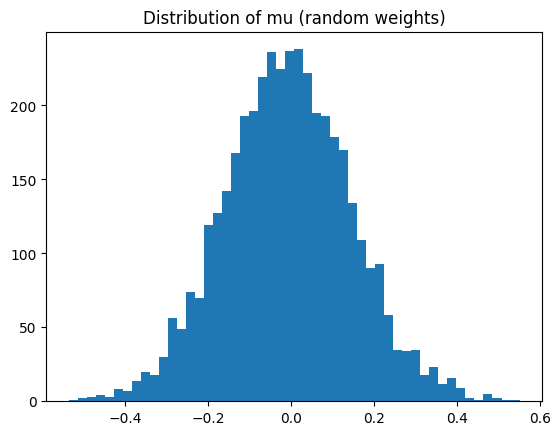

In [51]:
plt.figure()
plt.hist(mu.detach().numpy().flatten(), bins=50)
plt.title("Distribution of mu (random weights)")
plt.show()

In [52]:
print("Input:", x_in.shape)
print("Recon:", recon.shape)
print("Latent mu:", mu.shape)
print("Latent logvar:", logvar.shape)
print("Latent dim:", mu.shape[1])

Input: torch.Size([64, 7036])
Recon: torch.Size([64, 7036])
Latent mu: torch.Size([64, 64])
Latent logvar: torch.Size([64, 64])
Latent dim: 64


## Lightning Model and train_vae

In [53]:
from types import SimpleNamespace
from src.vae.lit_model import LitVAE
import numpy as np, torch

hp = {
  "seed": 0,
  "model": dict(latent_dim=64, hidden_channels=[64,128], kernel_size=17, stride=2, padding=8, use_batchnorm=False),
  "training": dict(lr=3e-4, beta=1e-3, weight_decay=1e-5),
  "masking": dict(enabled=True, alpha_masked=1.0, n_blocks=4, allow_overlap=True,
                  mask_frac=0.001, block_len=None, fill="gaussian", gaussian_std=0.1, constant_value=0.0)
}

# pretend you loaded your npy already:
X = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/processed_data/0/rep0/discovery_train.npy")
input_len = X.shape[1]

cfg = SimpleNamespace(
    input_len=input_len,
    latent_dim=hp["model"]["latent_dim"],
    hidden_channels=tuple(hp["model"]["hidden_channels"]),
    kernel_size=hp["model"]["kernel_size"],
    stride=hp["model"]["stride"],
    padding=hp["model"]["padding"],
    use_batchnorm=hp["model"]["use_batchnorm"],
    seed=hp["seed"],
    training=SimpleNamespace(**hp["training"]),
    masking=SimpleNamespace(**hp["masking"]),
)

lit = LitVAE(cfg)
print("cfg.training.beta =", lit._get_beta() if hasattr(lit, "_get_beta") else "no _get_beta")
print("mask enabled:", getattr(getattr(cfg, "masking", None), "enabled", None))
print("alpha_masked:", getattr(getattr(cfg, "masking", None), "alpha_masked", None))

cfg.training.beta = 0.001
mask enabled: True
alpha_masked: 1.0


In [54]:
x = torch.tensor(X[:64], dtype=torch.float32)
lit.eval()

# If you have _shared_step in LitVAE:
out = lit._shared_step((x,), batch_idx=0, stage="train")

print("Keys:", sorted(out.keys()))
for k in ["loss","recon_objective","kl","mse_masked","mse_unmasked","mse_clean_all","mask_frac","delta_in_l1"]:
    if k in out:
        print(k, float(out[k]))

Keys: ['delta_in_l1', 'kl', 'kl_clean', 'loss', 'mask_frac', 'mse_clean_all', 'mse_corrupt_all', 'mse_masked', 'mse_unmasked', 'ratio_masked_over_clean', 'recon_objective', 'used_block_len', 'x_in_max', 'x_max']
loss 1.9269851446151733
recon_objective 1.9259333610534668
kl 1.0517483949661255
mse_masked 1.9259333610534668
mse_unmasked 2.0061705112457275
mse_clean_all 2.009854793548584
mask_frac 0.0011347889667376876
delta_in_l1 0.0008286333759315312


In [55]:
from copy import deepcopy

cfg2 = deepcopy(cfg)

# alpha = 1.0 (pure inpainting)
cfg2.masking.alpha_masked = 1.0
lit1 = LitVAE(cfg2).eval()
o1 = lit1._shared_step((x,), batch_idx=0, stage="train")

# alpha = 0.0 (only unmasked loss)
cfg2.masking.alpha_masked = 0.0
lit0 = LitVAE(cfg2).eval()
o0 = lit0._shared_step((x,), batch_idx=0, stage="train")

print("alpha=1 recon_objective:", float(o1["recon_objective"]), "mse_masked:", float(o1["mse_masked"]))
print("alpha=0 recon_objective:", float(o0["recon_objective"]), "mse_unmasked:", float(o0["mse_unmasked"]))

alpha=1 recon_objective: 2.0426812171936035 mse_masked: 2.0426812171936035
alpha=0 recon_objective: 2.0097997188568115 mse_unmasked: 2.0097997188568115


## Trained model results

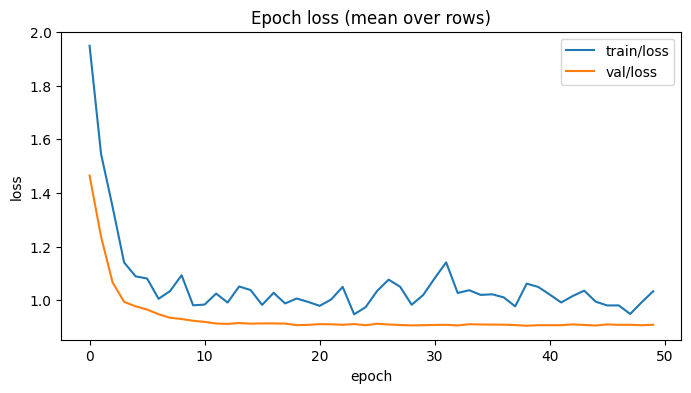

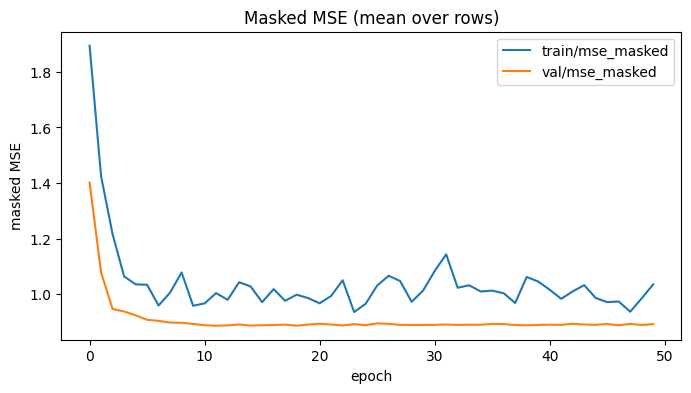

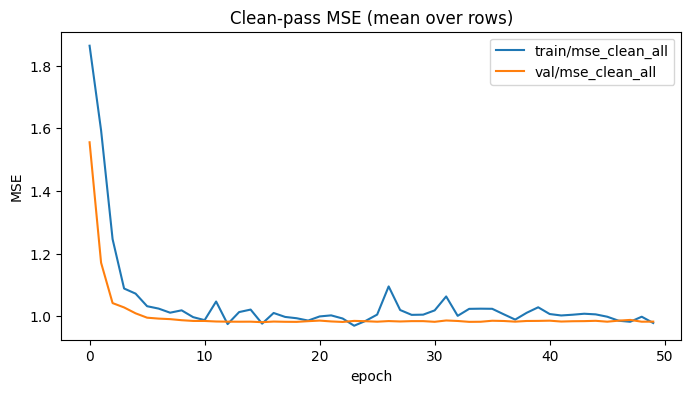

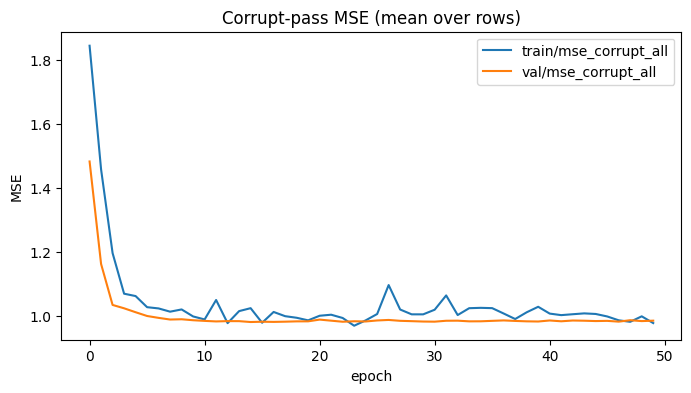

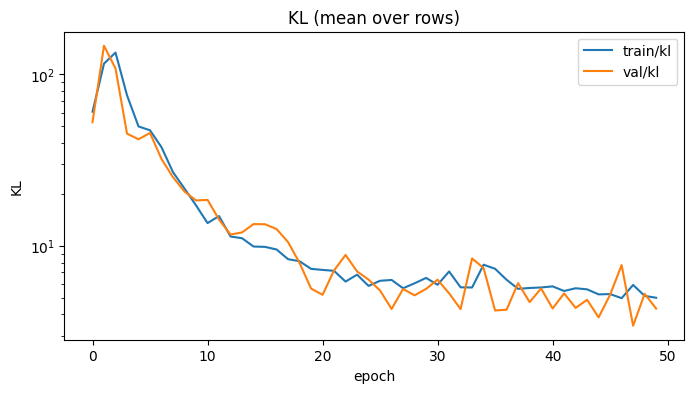

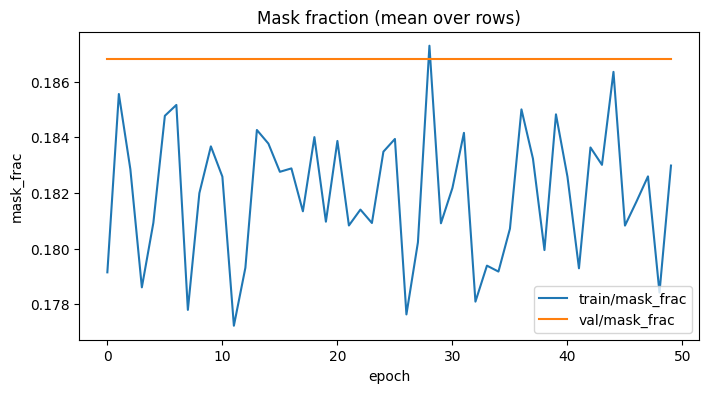

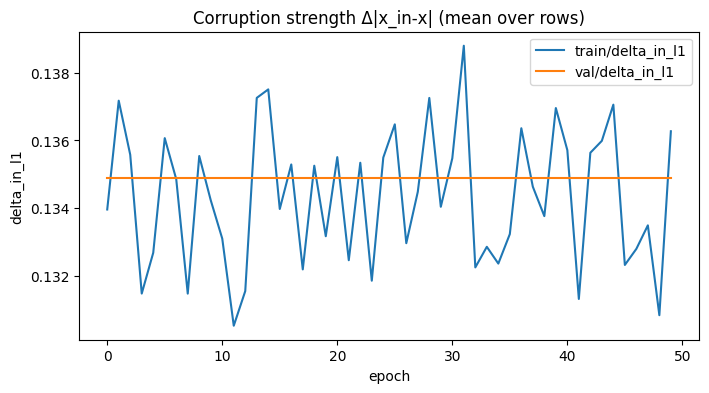

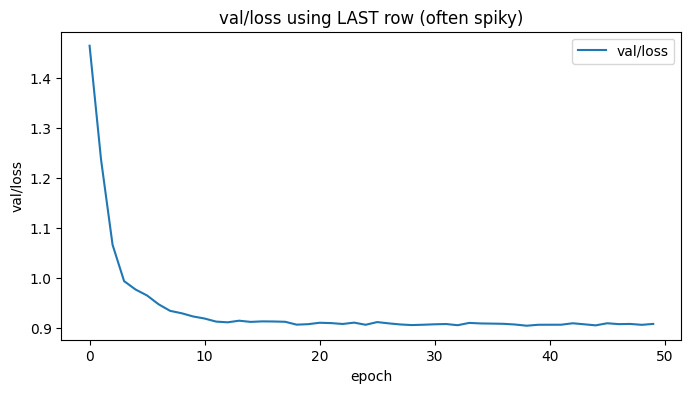

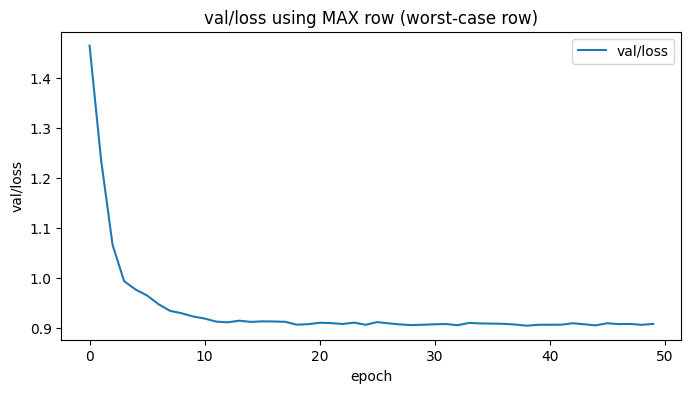

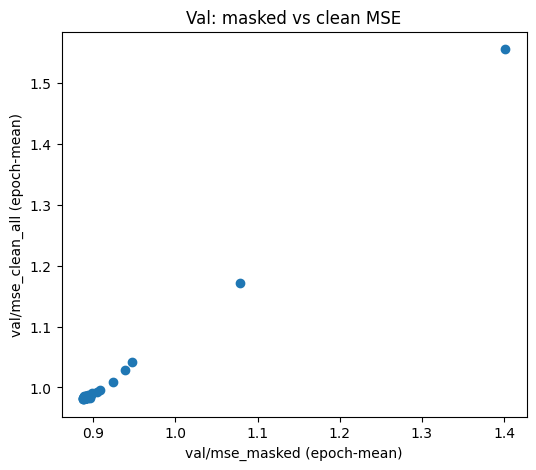

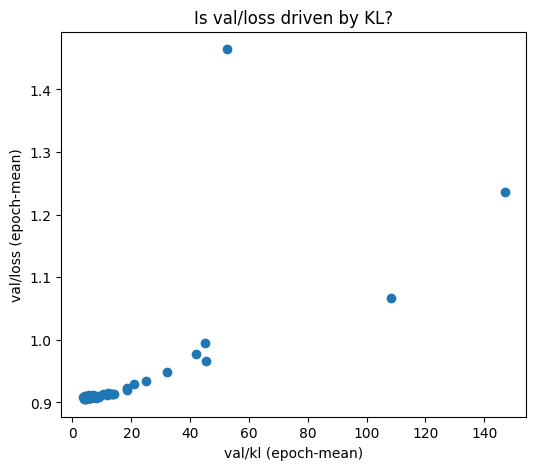

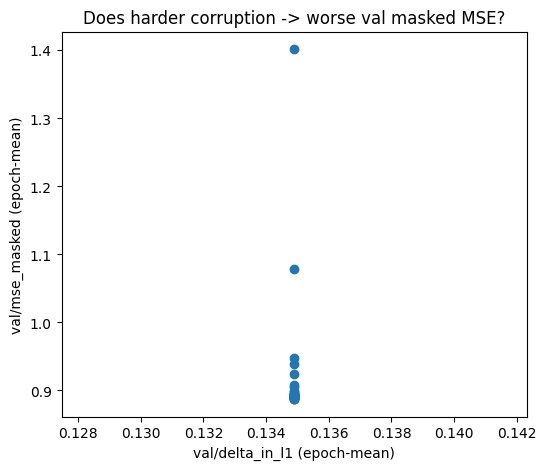

In [56]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

metrics_path = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/vae/default/0/rep0/logs/version_0/metrics.csv")
df = pd.read_csv(metrics_path)

# -----------------------------
# Helpers: robust epoch aggregation
# -----------------------------
def epoch_agg(cols, how="mean"):
    cols = [c for c in cols if c in df.columns]
    d = df[["epoch"] + cols].copy()
    d = d.dropna(subset=cols, how="all")

    g = d.groupby("epoch", as_index=False)

    if how == "mean":
        out = g[cols].mean(numeric_only=True)
    elif how == "median":
        out = g[cols].median(numeric_only=True)
    elif how == "max":
        out = g[cols].max(numeric_only=True)
    elif how == "last":
        out = g.last()
        out = out.reset_index()[["epoch"] + cols]
    else:
        raise ValueError("how must be one of: mean|median|max|last")

    return out.sort_values("epoch").reset_index(drop=True)

def plot_epoch(E, y1, y2=None, title=None, ylabel=None, logy=False):
    plt.figure(figsize=(8,4))
    plt.plot(E["epoch"], E[y1], label=y1)
    if y2 is not None and y2 in E.columns:
        plt.plot(E["epoch"], E[y2], label=y2)
    if logy:
        plt.yscale("log")
    plt.xlabel("epoch")
    plt.ylabel(ylabel if ylabel else y1)
    plt.title(title if title else f"{y1}" + (f" vs {y2}" if y2 else ""))
    plt.legend()
    plt.show()

# -----------------------------
# Choose metrics to inspect
# -----------------------------
cols = [
    "train/loss", "val/loss",
    "train/mse_masked", "val/mse_masked",
    "train/mse_clean_all", "val/mse_clean_all",
    "train/mse_corrupt_all", "val/mse_corrupt_all",
    "train/kl", "val/kl",
    "train/mask_frac", "val/mask_frac",
    "train/delta_in_l1", "val/delta_in_l1",  # how strong the corruption is
]

E_mean   = epoch_agg(cols, how="mean")
E_median = epoch_agg(cols, how="median")
E_max    = epoch_agg(cols, how="max")
E_last   = epoch_agg(cols, how="last")

# -----------------------------
# Core curves (MEAN is default)
# -----------------------------
plot_epoch(E_mean, "train/loss", "val/loss", title="Epoch loss (mean over rows)", ylabel="loss")
plot_epoch(E_mean, "train/mse_masked", "val/mse_masked", title="Masked MSE (mean over rows)", ylabel="masked MSE")
plot_epoch(E_mean, "train/mse_clean_all", "val/mse_clean_all", title="Clean-pass MSE (mean over rows)", ylabel="MSE")
if "train/mse_corrupt_all" in E_mean.columns and "val/mse_corrupt_all" in E_mean.columns:
    plot_epoch(E_mean, "train/mse_corrupt_all", "val/mse_corrupt_all", title="Corrupt-pass MSE (mean over rows)", ylabel="MSE")
plot_epoch(E_mean, "train/kl", "val/kl", title="KL (mean over rows)", ylabel="KL", logy=True)
plot_epoch(E_mean, "train/mask_frac", "val/mask_frac", title="Mask fraction (mean over rows)", ylabel="mask_frac")
if "train/delta_in_l1" in E_mean.columns and "val/delta_in_l1" in E_mean.columns:
    plot_epoch(E_mean, "train/delta_in_l1", "val/delta_in_l1", title="Corruption strength Δ|x_in-x| (mean over rows)", ylabel="delta_in_l1")

# -----------------------------
# Diagnostics: spikes due to aggregation?
# -----------------------------
plot_epoch(E_last, "val/loss", None, title="val/loss using LAST row (often spiky)", ylabel="val/loss")
plot_epoch(E_max,  "val/loss", None, title="val/loss using MAX row (worst-case row)", ylabel="val/loss")

# -----------------------------
# NEW: the diagnostic you asked for
# -----------------------------
# x-axis: val/mse_masked
# y-axis: val/mse_clean_all
plt.figure(figsize=(6,5))
plt.scatter(E_mean["val/mse_masked"], E_mean["val/mse_clean_all"])
plt.xlabel("val/mse_masked (epoch-mean)")
plt.ylabel("val/mse_clean_all (epoch-mean)")
plt.title("Val: masked vs clean MSE")
plt.show()

# Interpretation:
# - If val/mse_clean_all improves but val/mse_masked doesn't -> model is learning identity-ish recon, not inpainting.
# - If neither improves -> validation corruption/scale mismatch or real distribution shift.

# -----------------------------
# Extra: are val losses mostly KL-driven?
# -----------------------------
plt.figure(figsize=(6,5))
plt.scatter(E_mean["val/kl"], E_mean["val/loss"])
plt.xlabel("val/kl (epoch-mean)")
plt.ylabel("val/loss (epoch-mean)")
plt.title("Is val/loss driven by KL?")
plt.show()

# -----------------------------
# Extra: compare masking difficulty in val vs train
# -----------------------------
# If val is consistently harder (higher delta_in_l1 or higher mask_frac), val curves may not track train.
if "val/delta_in_l1" in E_mean.columns and "train/delta_in_l1" in E_mean.columns:
    plt.figure(figsize=(6,5))
    plt.scatter(E_mean["val/delta_in_l1"], E_mean["val/mse_masked"])
    plt.xlabel("val/delta_in_l1 (epoch-mean)")
    plt.ylabel("val/mse_masked (epoch-mean)")
    plt.title("Does harder corruption -> worse val masked MSE?")
    plt.show()

In [28]:
from pathlib import Path
import numpy as np

# -----------------------------
# Load your normalized arrays
# -----------------------------
root = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/processed_data/0/rep0")
X_train = np.load(root / "discovery_train.npy")   # (N_train, L)
X_val   = np.load(root / "discovery_val.npy")     # (N_val, L)

print("train:", X_train.shape, "val:", X_val.shape)
print("train mean/std:", X_train.mean(), X_train.std())
print("val   mean/std:", X_val.mean(), X_val.std())

# -----------------------------
# Mask helper (numpy version)
# matches your torch logic: pick random starts, make contiguous blocks, OR them
# -----------------------------
def make_multi_block_mask(B, L, block_len, n_blocks=1, seed=0, allow_overlap=True):
    rng = np.random.default_rng(seed)
    if block_len <= 0 or n_blocks <= 0:
        return np.zeros((B, L), dtype=bool)
    if block_len >= L:
        return np.ones((B, L), dtype=bool)

    mask = np.zeros((B, L), dtype=bool)

    if allow_overlap:
        starts = rng.integers(0, L, size=(B, n_blocks))
        for i in range(B):
            for b in range(n_blocks):
                s = int(starts[i, b])
                e = min(s + block_len, L)
                mask[i, s:e] = True
        return mask

    # best-effort non-overlap
    max_tries = 200
    for i in range(B):
        placed = 0
        tries = 0
        while placed < n_blocks and tries < max_tries:
            s = int(rng.integers(0, L))
            e = min(s + block_len, L)
            if not mask[i, s:e].any():
                mask[i, s:e] = True
                placed += 1
            tries += 1
    return mask

def resolve_block_len(L, block_len=None, mask_frac=None, n_blocks=1):
    if block_len is not None:
        return max(0, min(int(block_len), L))
    if mask_frac is None:
        return 0
    total = int(round(float(mask_frac) * L))
    total = max(1, min(total, L))
    per_block = int(round(total / int(n_blocks)))
    per_block = max(1, min(per_block, L))
    return per_block

def masked_mse(x, recon, mask, eps=1e-12):
    # x, recon: (B,L), mask bool: (B,L)
    diff2 = (recon - x) ** 2
    denom = mask.sum(axis=1, keepdims=True)  # (B,1)
    denom = np.maximum(denom, 1)            # avoid divide-by-zero
    per_sample = (diff2 * mask).sum(axis=1, keepdims=False) / denom[:, 0]
    return per_sample.mean()

# -----------------------------
# Baselines to compare against
# -----------------------------
def baseline_zero(x):
    return np.zeros_like(x)

def baseline_mean(x):
    # per-SNP mean within the *batch*; this is a strong baseline if things are standardized
    m = x.mean(axis=0, keepdims=True)
    return np.repeat(m, x.shape[0], axis=0)

# -----------------------------
# Run baseline evaluation
# -----------------------------
def eval_baselines(X, split_name, *, mask_frac=0.20, block_len=None, n_blocks=4, allow_overlap=True, seed=0):
    B, L = X.shape
    used_bl = resolve_block_len(L, block_len=block_len, mask_frac=mask_frac, n_blocks=n_blocks)
    mask = make_multi_block_mask(B, L, used_bl, n_blocks=n_blocks, seed=seed, allow_overlap=allow_overlap)
    frac_realized = mask.mean()

    recon0 = baseline_zero(X)
    reconm = baseline_mean(X)

    mse0 = masked_mse(X, recon0, mask)
    msem = masked_mse(X, reconm, mask)

    print(f"[{split_name}] L={L} used_block_len={used_bl} n_blocks={n_blocks} realized_mask_frac={frac_realized:.4f}")
    print(f"[{split_name}] baseline ZERO masked MSE : {mse0:.6f}")
    print(f"[{split_name}] baseline MEAN masked MSE : {msem:.6f}")
    return {"used_block_len": used_bl, "mask_frac": float(frac_realized), "mse_zero": float(mse0), "mse_mean": float(msem)}

# Use the same masking config you trained with:
cfg = dict(mask_frac=0.20, block_len=None, n_blocks=4, allow_overlap=True, seed=123)

train_base = eval_baselines(X_train, "train", **cfg)
val_base   = eval_baselines(X_val,   "val",   **cfg)

train: (400, 7036) val: (100, 7036)
train mean/std: 1.734939e-10 0.9997112
val   mean/std: 0.00021638854 1.0078791
[train] L=7036 used_block_len=352 n_blocks=4 realized_mask_frac=0.1798
[train] baseline ZERO masked MSE : 0.987841
[train] baseline MEAN masked MSE : 0.987841
[val] L=7036 used_block_len=352 n_blocks=4 realized_mask_frac=0.1806
[val] baseline ZERO masked MSE : 1.002112
[val] baseline MEAN masked MSE : 0.990776


In [29]:
# create mask for validation set

B, L = X_val.shape

block_len = 352
n_blocks = 4

mask = make_multi_block_mask(
    B,
    L,
    block_len,
    n_blocks=n_blocks,
    seed=123,
    allow_overlap=True
)

print("mask fraction:", mask.mean())

mask fraction: 0.1805955088118249


In [30]:
baseline_pred = np.zeros_like(X_val)

baseline_mse = masked_mse(X_val, baseline_pred, mask)

print("AF baseline masked MSE:", baseline_mse)

AF baseline masked MSE: 1.0021120071245846


In [31]:
rng = np.random.default_rng(0)

X_in = X_val.copy()

X_in[mask] = rng.normal(
    0,
    0.1,
    size=mask.sum()
)

In [32]:
import torch

model.eval()

with torch.no_grad():

    x_tensor = torch.tensor(X_in).float()

    recon, mu, logvar = model(x_tensor)

    recon = recon.cpu().numpy()

/sietch_colab/akapoor/PRS_Portability/src/vae/model.py:115: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=False):


In [34]:
model_mse = masked_mse(X_val, recon, mask)

print("AF baseline MSE:", baseline_mse)
print("Model masked MSE:", model_mse)

AF baseline MSE: 1.0021120071245846
Model masked MSE: 2.055653651845993
